# LIBRARY

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# EXPLORATION

In [204]:
file_path = "../1.DATASET/cmi_internet.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


In [205]:
df.shape

(8460, 82)

## Info from columns

### general

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Enroll_Season               8460 non-null   object 
 2   Basic_Demos-Age                         8460 non-null   int64  
 3   Basic_Demos-Sex                         8460 non-null   int64  
 4   CGAS-Season                             7158 non-null   object 
 5   CGAS-CGAS_Score                         7034 non-null   float64
 6   Physical-Season                         7858 non-null   object 
 7   Physical-BMI                            7591 non-null   float64
 8   Physical-Height                         7595 non-null   float64
 9   Physical-Weight                         7641 non-null   float64
 10  Physical-Waist_Circumference            5624 non-null   floa

In [207]:
for name in df.columns:
    print(name, df[name].isnull().sum())

id 0
Basic_Demos-Enroll_Season 0
Basic_Demos-Age 0
Basic_Demos-Sex 0
CGAS-Season 1302
CGAS-CGAS_Score 1426
Physical-Season 602
Physical-BMI 869
Physical-Height 865
Physical-Weight 819
Physical-Waist_Circumference 2836
Physical-Diastolic_BP 932
Physical-HeartRate 921
Physical-Systolic_BP 932
Fitness_Endurance-Season 2456
Fitness_Endurance-Max_Stage 2980
Fitness_Endurance-Time_Mins 2982
Fitness_Endurance-Time_Sec 2982
FGC-Season 569
FGC-FGC_CU 1517
FGC-FGC_CU_Zone 1554
FGC-FGC_GSND 2673
FGC-FGC_GSND_Zone 2684
FGC-FGC_GSD 2673
FGC-FGC_GSD_Zone 2684
FGC-FGC_PU 1528
FGC-FGC_PU_Zone 1565
FGC-FGC_SRL 1534
FGC-FGC_SRL_Zone 1569
FGC-FGC_SRR 1532
FGC-FGC_SRR_Zone 1567
FGC-FGC_TL 1515
FGC-FGC_TL_Zone 1552
BIA-Season 1682
BIA-BIA_Activity_Level_num 1824
BIA-BIA_BMC 1824
BIA-BIA_BMI 1824
BIA-BIA_BMR 1824
BIA-BIA_DEE 1824
BIA-BIA_ECW 1824
BIA-BIA_FFM 1824
BIA-BIA_FFMI 1824
BIA-BIA_FMI 1824
BIA-BIA_Fat 1824
BIA-BIA_Frame_num 1824
BIA-BIA_ICW 1824
BIA-BIA_LDM 1824
BIA-BIA_LST 1824
BIA-BIA_SMM 1824
BIA

In [208]:
df.values[[1],:]

array([[1, 'Summer', 9, 0, nan, nan, 'Fall', 14.03559028, 48.0, 46.0,
        22.0, 75.0, 70.0, 122.0, nan, nan, nan, 28.0, 'Fall', 3.0, 0.0,
        nan, 2.0, nan, 2.0, 5.0, 0.0, 11.0, 1.0, 11.0, 1.0, 3.0, 0.0,
        'Winter', 2.0, 2.57949, 14.0371, 936.656, 1498.65, 6.01993,
        42.0291, 12.8254, 1.21172, 3.97085, 1.0, 21.0352, 14.974,
        39.4497, 15.4107, 27.0552, 'Winter', 2.01, 'Fall', 2.34, 'Fall',
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 'Fall', 46.0, 64.0,
        'Summer', 0.0, 0.0]], dtype=object)

In [209]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")


### Basic_Demos-Age

In [210]:
analyze_feature(df, "Basic_Demos-Age")

Analyzed column: Basic_Demos-Age
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 5
Maximum value: 22
Range (max - min): 17

Quantiles:
  Q10 (0.1): 6.0
  Q25 (0.25): 7.0
  Q50 (0.5): 10.0
  Q75 (0.75): 12.0
  Q90 (0.9): 16.0
  Q99 (0.99): 19.0


### Basic_Demos-Sex

In [211]:
analyze_feature(df, "Basic_Demos-Sex")

Analyzed column: Basic_Demos-Sex
Presence of values equal to 0: True
Number of values equal to 0: 5056
Presence of negative values: False
Number of negative values: 0
Minimum value: 0
Maximum value: 1
Range (max - min): 1

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 0.0
  Q75 (0.75): 1.0
  Q90 (0.9): 1.0
  Q99 (0.99): 1.0


### CGAS-CGAS_Score

In [212]:
analyze_feature(df, "CGAS-CGAS_Score")

Analyzed column: CGAS-CGAS_Score
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 25.0
Maximum value: 999.0
Range (max - min): 974.0

Quantiles:
  Q10 (0.1): 53.5
  Q25 (0.25): 60.5
  Q50 (0.5): 65.0
  Q75 (0.75): 70.5
  Q90 (0.9): 80.0
  Q99 (0.99): 88.0


### Physical-BMI

In [213]:
analyze_feature(df, "Physical-BMI")

Analyzed column: Physical-BMI
Presence of values equal to 0: True
Number of values equal to 0: 7
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 59.13204775
Range (max - min): 59.13204775

Quantiles:
  Q10 (0.1): 15.377841230418818
  Q25 (0.25): 16.54174150527521
  Q50 (0.5): 17.937682125000002
  Q75 (0.75): 21.46954632
  Q90 (0.9): 25.19803833701665
  Q99 (0.99): 36.530021757291166


### Physical-Height

In [214]:
analyze_feature(df, "Physical-Height")

Analyzed column: Physical-Height
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 33.0
Maximum value: 78.5
Range (max - min): 45.5

Quantiles:
  Q10 (0.1): 48.11
  Q25 (0.25): 51.5
  Q50 (0.5): 55.7
  Q75 (0.75): 63.0
  Q90 (0.9): 67.976
  Q99 (0.99): 73.6206


### Physical-Weight

In [215]:
analyze_feature(df, "Physical-Weight")

Analyzed column: Physical-Weight
Presence of values equal to 0: True
Number of values equal to 0: 81
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 315.0
Range (max - min): 315.0

Quantiles:
  Q10 (0.1): 45.2
  Q25 (0.25): 55.2
  Q50 (0.5): 75.0
  Q75 (0.75): 107.0
  Q90 (0.9): 138.8
  Q99 (0.99): 217.72000000000043


### Physical-Waist_Circumference

In [216]:
analyze_feature(df, "Physical-Waist_Circumference")

Analyzed column: Physical-Waist_Circumference
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 18.0
Maximum value: 50.0
Range (max - min): 32.0

Quantiles:
  Q10 (0.1): 23.1
  Q25 (0.25): 25.0
  Q50 (0.5): 26.0
  Q75 (0.75): 28.25
  Q90 (0.9): 31.5
  Q99 (0.99): 40.75


### Physical-Diastolic_BP

In [217]:
analyze_feature(df, "Physical-Diastolic_BP")

Analyzed column: Physical-Diastolic_BP
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 179.0
Range (max - min): 179.0

Quantiles:
  Q10 (0.1): 57.5
  Q25 (0.25): 62.5
  Q50 (0.5): 68.0
  Q75 (0.75): 72.5
  Q90 (0.9): 82.0
  Q99 (0.99): 108.36499999999978


### Physical-HeartRate

In [218]:
analyze_feature(df, "Physical-HeartRate")

Analyzed column: Physical-HeartRate
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 27.0
Maximum value: 138.0
Range (max - min): 111.0

Quantiles:
  Q10 (0.1): 68.0
  Q25 (0.25): 75.5
  Q50 (0.5): 81.5
  Q75 (0.75): 87.0
  Q90 (0.9): 97.0
  Q99 (0.99): 114.0


### Physical-Systolic_BP

In [219]:
analyze_feature(df, "Physical-Systolic_BP")

Analyzed column: Physical-Systolic_BP
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 203.0
Range (max - min): 203.0

Quantiles:
  Q10 (0.1): 101.0
  Q25 (0.25): 108.5
  Q50 (0.5): 114.0
  Q75 (0.75): 121.0
  Q90 (0.9): 133.0
  Q99 (0.99): 163.5


### Fitness_Endurance-Max_Stage

In [220]:
analyze_feature(df, "Fitness_Endurance-Max_Stage")

Analyzed column: Fitness_Endurance-Max_Stage
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 28.0
Range (max - min): 28.0

Quantiles:
  Q10 (0.1): 4.0
  Q25 (0.25): 4.5
  Q50 (0.5): 5.0
  Q75 (0.75): 5.0
  Q90 (0.9): 6.0
  Q99 (0.99): 7.5


### Fitness_Endurance-Time_Mins

In [221]:
analyze_feature(df, "Fitness_Endurance-Time_Mins")

Analyzed column: Fitness_Endurance-Time_Mins
Presence of values equal to 0: True
Number of values equal to 0: 37
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 20.0
Range (max - min): 20.0

Quantiles:
  Q10 (0.1): 5.5
  Q25 (0.25): 7.0
  Q50 (0.5): 7.0
  Q75 (0.75): 7.5
  Q90 (0.9): 8.5
  Q99 (0.99): 11.0


### Fitness_Endurance-Time_Sec

In [222]:
analyze_feature(df, "Fitness_Endurance-Time_Sec")

Analyzed column: Fitness_Endurance-Time_Sec
Presence of values equal to 0: True
Number of values equal to 0: 76
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 59.0
Range (max - min): 59.0

Quantiles:
  Q10 (0.1): 15.5
  Q25 (0.25): 27.0
  Q50 (0.5): 28.0
  Q75 (0.75): 28.5
  Q90 (0.9): 39.5
  Q99 (0.99): 56.0


### FGC-FGC_CU

In [223]:
analyze_feature(df, "FGC-FGC_CU")

Analyzed column: FGC-FGC_CU
Presence of values equal to 0: True
Number of values equal to 0: 808
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 115.0
Range (max - min): 115.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 3.5
  Q50 (0.5): 9.0
  Q75 (0.75): 12.5
  Q90 (0.9): 20.5
  Q99 (0.99): 42.0


### FGC-FGC_GSND

In [224]:
analyze_feature(df, "FGC-FGC_GSND")

Analyzed column: FGC-FGC_GSND
Presence of values equal to 0: True
Number of values equal to 0: 42
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 124.0
Range (max - min): 124.0

Quantiles:
  Q10 (0.1): 13.4
  Q25 (0.25): 17.3
  Q50 (0.5): 19.0
  Q75 (0.75): 20.05
  Q90 (0.9): 27.1
  Q99 (0.99): 45.714000000000034


### FGC-FGC_GSD

In [225]:
analyze_feature(df, "FGC-FGC_GSD")

Analyzed column: FGC-FGC_GSD
Presence of values equal to 0: True
Number of values equal to 0: 34
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 123.8
Range (max - min): 123.8

Quantiles:
  Q10 (0.1): 14.5
  Q25 (0.25): 18.75
  Q50 (0.5): 19.8
  Q75 (0.75): 21.2
  Q90 (0.9): 29.4
  Q99 (0.99): 46.61400000000003


### FGC-FGC_PU

In [226]:
analyze_feature(df, "FGC-FGC_PU")

Analyzed column: FGC-FGC_PU
Presence of values equal to 0: True
Number of values equal to 0: 2001
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 51.0
Range (max - min): 51.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 3.0
  Q75 (0.75): 7.0
  Q90 (0.9): 11.0
  Q99 (0.99): 27.0


### FGC-FGC_SRL

In [227]:
analyze_feature(df, "FGC-FGC_SRL")

Analyzed column: FGC-FGC_SRL
Presence of values equal to 0: True
Number of values equal to 0: 154
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 21.7
Range (max - min): 21.7

Quantiles:
  Q10 (0.1): 5.0
  Q25 (0.25): 7.0
  Q50 (0.5): 9.0
  Q75 (0.75): 10.0
  Q90 (0.9): 11.5
  Q99 (0.99): 15.0


### FGC-FGC_SRR

In [228]:
analyze_feature(df, "FGC-FGC_SRR")

Analyzed column: FGC-FGC_SRR
Presence of values equal to 0: True
Number of values equal to 0: 188
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 21.0
Range (max - min): 21.0

Quantiles:
  Q10 (0.1): 4.5
  Q25 (0.25): 7.0
  Q50 (0.5): 9.0
  Q75 (0.75): 9.0
  Q90 (0.9): 11.0
  Q99 (0.99): 15.0


### FGC-FGC_TL

In [229]:
analyze_feature(df, "FGC-FGC_TL")

Analyzed column: FGC-FGC_TL
Presence of values equal to 0: True
Number of values equal to 0: 19
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 22.0
Range (max - min): 22.0

Quantiles:
  Q10 (0.1): 5.0
  Q25 (0.25): 8.0
  Q50 (0.5): 9.0
  Q75 (0.75): 10.0
  Q90 (0.9): 12.0
  Q99 (0.99): 14.0


### BIA-BIA_Activity_Level_num

In [230]:
analyze_feature(df, "BIA-BIA_Activity_Level_num")

Analyzed column: BIA-BIA_Activity_Level_num
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.0
Maximum value: 5.0
Range (max - min): 4.0

Quantiles:
  Q10 (0.1): 2.0
  Q25 (0.25): 2.0
  Q50 (0.5): 3.0
  Q75 (0.75): 3.0
  Q90 (0.9): 4.0
  Q99 (0.99): 5.0


### BIA-BIA_BMC

In [231]:
analyze_feature(df, "BIA-BIA_BMC")

Analyzed column: BIA-BIA_BMC
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 34
Minimum value: -7.78961
Maximum value: 4115.36
Range (max - min): 4123.1496099999995

Quantiles:
  Q10 (0.1): 2.8636041309125146
  Q25 (0.25): 3.769004347057183
  Q50 (0.5): 4.242370643381097
  Q75 (0.75): 5.439065690054887
  Q90 (0.9): 6.6629750243005414
  Q99 (0.99): 12.088429999999988


### BIA-BIA_BMI

In [232]:
analyze_feature(df, "BIA-BIA_BMI")

Analyzed column: BIA-BIA_BMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0482667
Maximum value: 53.9243
Range (max - min): 53.8760333

Quantiles:
  Q10 (0.1): 15.456626761872851
  Q25 (0.25): 16.4883
  Q50 (0.5): 17.9665
  Q75 (0.75): 20.361186199282983
  Q90 (0.9): 23.737040529122105
  Q99 (0.99): 34.870906725865446


### BIA-BIA_BMR

In [233]:
analyze_feature(df, "BIA-BIA_BMR")

Analyzed column: BIA-BIA_BMR
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 813.397
Maximum value: 83152.2
Range (max - min): 82338.803

Quantiles:
  Q10 (0.1): 966.8428501684696
  Q25 (0.25): 1035.5406853237596
  Q50 (0.5): 1115.38
  Q75 (0.75): 1292.3360175505343
  Q90 (0.9): 1464.5442941564302
  Q99 (0.99): 1986.367253865123


### BIA-BIA_DEE

In [234]:
analyze_feature(df, "BIA-BIA_DEE")

Analyzed column: BIA-BIA_DEE
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1073.45
Maximum value: 124728.0
Range (max - min): 123654.55

Quantiles:
  Q10 (0.1): 1424.0364353734326
  Q25 (0.25): 1583.762570812826
  Q50 (0.5): 1822.190646711037
  Q75 (0.75): 2003.8725
  Q90 (0.9): 2451.3474359430575
  Q99 (0.99): 3534.0904999999984


### BIA-BIA_ECW

In [235]:
analyze_feature(df, "BIA-BIA_ECW")

Analyzed column: BIA-BIA_ECW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.78945
Maximum value: 3233.0
Range (max - min): 3231.21055

Quantiles:
  Q10 (0.1): 9.385901988211497
  Q25 (0.25): 12.166445119706793
  Q50 (0.5): 15.928
  Q75 (0.75): 23.206683582586592
  Q90 (0.9): 32.22575
  Q99 (0.99): 52.66177867256066


### BIA-BIA_FFM

In [236]:
analyze_feature(df, "BIA-BIA_FFM")

Analyzed column: BIA-BIA_FFM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 28.9004
Maximum value: 8799.08
Range (max - min): 8770.1796

Quantiles:
  Q10 (0.1): 43.42977098261872
  Q25 (0.25): 50.738330740293144
  Q50 (0.5): 61.0662
  Q75 (0.75): 76.74912499999999
  Q90 (0.9): 96.90124835684448
  Q99 (0.99): 161.14111338448637


### BIA-BIA_FFMI

In [237]:
analyze_feature(df, "BIA-BIA_FFMI")

Analyzed column: BIA-BIA_FFMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 7.86485
Maximum value: 217.771
Range (max - min): 209.90615

Quantiles:
  Q10 (0.1): 13.333477381834754
  Q25 (0.25): 13.70382585004337
  Q50 (0.5): 14.0925
  Q75 (0.75): 14.942126000761185
  Q90 (0.9): 17.282655958892434
  Q99 (0.99): 23.663085232034337


### BIA-BIA_FMI

In [238]:
analyze_feature(df, "BIA-BIA_FMI")

Analyzed column: BIA-BIA_FMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 51
Minimum value: -194.163
Maximum value: 28.2515
Range (max - min): 222.4145

Quantiles:
  Q10 (0.1): 2.093789792266045
  Q25 (0.25): 2.927146459348925
  Q50 (0.5): 3.69863
  Q75 (0.75): 5.575318058289664
  Q90 (0.9): 8.714952572292859
  Q99 (0.99): 18.138368204389526


### BIA-BIA_Fat

In [239]:
analyze_feature(df, "BIA-BIA_Fat")

Analyzed column: BIA-BIA_Fat
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 112
Minimum value: -8745.08
Maximum value: 153.82
Range (max - min): 8898.9

Quantiles:
  Q10 (0.1): 6.026138298784387
  Q25 (0.25): 10.636588401056262
  Q50 (0.5): 16.1746
  Q75 (0.75): 28.521910700742637
  Q90 (0.9): 42.99897982826643
  Q99 (0.99): 95.7090699999999


### BIA-BIA_Frame_num

In [240]:
analyze_feature(df, "BIA-BIA_Frame_num")

Analyzed column: BIA-BIA_Frame_num
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.0
Maximum value: 3.0
Range (max - min): 2.0

Quantiles:
  Q10 (0.1): 1.0
  Q25 (0.25): 1.0
  Q50 (0.5): 2.0
  Q75 (0.75): 2.0
  Q90 (0.9): 2.0
  Q99 (0.99): 3.0


### BIA-BIA_ICW

In [241]:
analyze_feature(df, "BIA-BIA_ICW")

Analyzed column: BIA-BIA_ICW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 14.489
Maximum value: 2457.91
Range (max - min): 2443.421

Quantiles:
  Q10 (0.1): 21.66631952013813
  Q25 (0.25): 24.264761762527954
  Q50 (0.5): 28.8558
  Q75 (0.75): 32.487041951256614
  Q90 (0.9): 43.86829509045954
  Q99 (0.99): 66.23371999999995


### BIA-BIA_LDM

In [242]:
analyze_feature(df, "BIA-BIA_LDM")

Analyzed column: BIA-BIA_LDM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 4.63581
Maximum value: 3108.17
Range (max - min): 3103.53419

Quantiles:
  Q10 (0.1): 12.662700000000001
  Q25 (0.25): 15.32511008495633
  Q50 (0.5): 16.808139893613312
  Q75 (0.75): 22.476325
  Q90 (0.9): 29.65103510943078
  Q99 (0.99): 47.68614766586142


### BIA-BIA_LST

In [243]:
analyze_feature(df, "BIA-BIA_LST")

Analyzed column: BIA-BIA_LST
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 23.6201
Maximum value: 4683.71
Range (max - min): 4660.0899

Quantiles:
  Q10 (0.1): 40.835810919243556
  Q25 (0.25): 47.90185386986214
  Q50 (0.5): 56.9964
  Q75 (0.75): 71.41752498053663
  Q90 (0.9): 94.9697964384264
  Q99 (0.99): 148.4579318668167


### BIA-BIA_SMM

In [244]:
analyze_feature(df, "BIA-BIA_SMM")

Analyzed column: BIA-BIA_SMM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 4.65573
Maximum value: 3607.69
Range (max - min): 3603.03427

Quantiles:
  Q10 (0.1): 19.31512658984242
  Q25 (0.25): 23.035193499752122
  Q50 (0.5): 27.4151
  Q75 (0.75): 37.595335982064654
  Q90 (0.9): 48.7762
  Q99 (0.99): 94.94377


### BIA-BIA_TBW

In [245]:
analyze_feature(df, "BIA-BIA_TBW")

Analyzed column: BIA-BIA_TBW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 20.5892
Maximum value: 5690.91
Range (max - min): 5670.3207999999995

Quantiles:
  Q10 (0.1): 29.66890312456711
  Q25 (0.25): 34.80221730985009
  Q50 (0.5): 44.987
  Q75 (0.75): 53.42277859716289
  Q90 (0.9): 69.49260000000001
  Q99 (0.99): 113.56004999999983


### PAQ_A-PAQ_A_Total

In [246]:
analyze_feature(df, "PAQ_A-PAQ_A_Total")

Analyzed column: PAQ_A-PAQ_A_Total
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.66
Maximum value: 5.0
Range (max - min): 4.34

Quantiles:
  Q10 (0.1): 2.0
  Q25 (0.25): 2.0
  Q50 (0.5): 2.0
  Q75 (0.75): 2.01
  Q90 (0.9): 2.01
  Q99 (0.99): 3.506999999999998


In [247]:
df['PAQ_A-PAQ_A_Total'].value_counts()

PAQ_A-PAQ_A_Total
2.000    2746
2.010    1744
3.000     162
1.000      95
4.000      14
         ... 
3.440       1
3.131       1
3.090       1
3.330       1
1.790       1
Name: count, Length: 257, dtype: int64

In [248]:
df[['Basic_Demos-Age','PAQ_A-PAQ_A_Total']][(df['Basic_Demos-Age']<9) & df['PAQ_A-PAQ_A_Total'].notna()]

,Basic_Demos-Age,PAQ_A-PAQ_A_Total
27,6,2.01
36,7,2.01
38,6,2.01
44,7,2.01
74,6,2.01
...,...,...
8439,6,2.00
8446,7,2.00
8449,8,2.00
8450,6,2.00


In [249]:
df[['Basic_Demos-Age','PAQ_A-PAQ_A_Total']].groupby('Basic_Demos-Age')

### PAQ_C-PAQ_C_Total

In [250]:
analyze_feature(df, "PAQ_C-PAQ_C_Total")

Analyzed column: PAQ_C-PAQ_C_Total
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.58
Maximum value: 5.0
Range (max - min): 4.42

Quantiles:
  Q10 (0.1): 1.99
  Q25 (0.25): 2.12
  Q50 (0.5): 2.7
  Q75 (0.75): 3.0
  Q90 (0.9): 3.27
  Q99 (0.99): 4.081599999999999


In [251]:
df[['Basic_Demos-Age','PAQ_C-PAQ_C_Total']][(df['Basic_Demos-Age']>9) & df['PAQ_C-PAQ_C_Total'].notna()]

,Basic_Demos-Age,PAQ_C-PAQ_C_Total
2,10,2.17
5,13,4.11
6,10,3.67
7,10,1.27
8,15,2.54
...,...,...
8447,10,1.00
8451,14,3.00
8456,10,3.00
8457,10,2.00


### PCIAT-PCIAT

In [252]:
analyze_feature(df, "PCIAT-PCIAT_20")

Analyzed column: PCIAT-PCIAT_20
Presence of values equal to 0: True
Number of values equal to 0: 1240
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 5.0
Range (max - min): 5.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 1.0
  Q75 (0.75): 1.0
  Q90 (0.9): 2.0
  Q99 (0.99): 5.0


### PCIAT-PCIAT_Total

In [253]:
cols_to_sum = ['PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
       'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
       'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
       'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
       'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
       'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20']
 
# compute the sum
df['sum_20'] = df[cols_to_sum].sum(axis=1)
 
# compare with target column
df['comparison'] = df['sum_20'] == df['PCIAT-PCIAT_Total']

In [254]:
df[['id','sum_20','PCIAT-PCIAT_Total']][(df['comparison']==False) & (df['PCIAT-PCIAT_Total'].notna()) ]

,id,sum_20,PCIAT-PCIAT_Total
24,24,31.0,30.0
141,141,27.0,26.0
255,255,82.0,81.0
270,270,49.0,48.0
425,425,7.0,5.0
944,944,54.0,53.0
1120,1120,59.0,56.0
1247,1247,41.0,40.0
1387,1387,65.0,64.0
1472,1472,75.0,74.0


In [255]:
df[['id','sum_20','PCIAT-PCIAT_Total']][(df['comparison']==False)  ]

,id,sum_20,PCIAT-PCIAT_Total
4,4,0.0,NaN
7,7,0.0,NaN
8,8,0.0,NaN
9,9,0.0,NaN
10,10,0.0,NaN
...,...,...,...
8455,8455,0.0,NaN
8456,8456,0.0,NaN
8457,8457,0.0,NaN
8458,8458,0.0,NaN


### PreInt_EduHx-computerinternet_hoursday

In [256]:
analyze_feature(df, "PreInt_EduHx-computerinternet_hoursday")

Analyzed column: PreInt_EduHx-computerinternet_hoursday
Presence of values equal to 0: True
Number of values equal to 0: 3634
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 3.0
Range (max - min): 3.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 1.0
  Q75 (0.75): 2.0
  Q90 (0.9): 2.0
  Q99 (0.99): 3.0


### SDS-SDS_Total_Raw

In [257]:
analyze_feature(df, "SDS-SDS_Total_Raw")

Analyzed column: SDS-SDS_Total_Raw
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 17.0
Maximum value: 96.0
Range (max - min): 79.0

Quantiles:
  Q10 (0.1): 31.0
  Q25 (0.25): 35.0
  Q50 (0.5): 39.5
  Q75 (0.75): 45.0
  Q90 (0.9): 54.0
  Q99 (0.99): 72.0


### SDS-SDS_Total_T

In [258]:
analyze_feature(df, "SDS-SDS_Total_T")

Analyzed column: SDS-SDS_Total_T
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 38.0
Maximum value: 100.0
Range (max - min): 62.0

Quantiles:
  Q10 (0.1): 45.0
  Q25 (0.25): 50.0
  Q50 (0.5): 55.0
  Q75 (0.75): 62.5
  Q90 (0.9): 76.0
  Q99 (0.99): 100.0


## unique values 

In [259]:
df['Basic_Demos-Sex'].value_counts()

Basic_Demos-Sex
0    5056
1    3404
Name: count, dtype: int64

In [260]:
df[(df['CGAS-Season']!=df['Physical-Season']) & (df['Physical-Season'].notna()) & (df['CGAS-Season'].notna())].shape

(5076, 84)

## CALCULATION 

### BMI CALCULATOR

In [261]:
df['Physical-BMI_CAL']=(df['Physical-Weight']/(df['Physical-Height']*df['Physical-Height']))*703

In [262]:
df['Physical-BMI_CAL2']=(df['BIA-BIA_FFMI']+df['BIA-BIA_FMI'])
df[["Physical-BMI_CAL2","Physical-BMI"]][(round(df["Physical-BMI"],0)==round(df["Physical-BMI_CAL2"],0))
                                         #& (df["Physical-BMI_CAL2"].notna()) & (df["Physical-BMI"].notna())
                                         ]

,Physical-BMI_CAL2,Physical-BMI
0,16.879130,16.877316
1,14.037120,14.035590
3,18.294330,18.292347
6,19.662910,19.660760
7,16.863150,16.861286
...,...,...
8403,18.810965,19.044373
8418,17.026770,16.789664
8419,17.497967,17.394705
8428,21.738182,21.637708


In [263]:
df[["Basic_Demos-Age",'Physical-Weight','Physical-Height',"Physical-BMI_CAL","Physical-BMI","Physical-BMI_CAL2"]][#(round(df["Physical-BMI_CAL2"],0)==round(df["Physical-BMI_CAL"],0))
                                          (df["Physical-BMI_CAL"].notna())
                                          & (df["Physical-BMI"].isna())
                                          #&(df['Physical-BMI_CAL']!=0)
                                          #& (df["Physical-BMI"].isna())
                                          & (df["Physical-BMI_CAL2"]!=17.79113)
                                          & (df["Physical-BMI_CAL2"].notna())
                                          ]

,Basic_Demos-Age,Physical-Weight,Physical-Height,Physical-BMI_CAL,Physical-BMI,Physical-BMI_CAL2
897,15,0.0,55.00,0.000000,NaN,21.926810
1426,12,77.0,55.00,17.894545,NaN,25.243560
3875,14,77.0,55.00,17.894545,NaN,23.270020
3993,8,57.2,55.12,13.235274,NaN,18.028021
4004,10,68.3,54.90,15.930571,NaN,16.418933
...,...,...,...,...,...,...
8352,11,107.4,58.28,22.229030,NaN,22.233250
8393,5,42.8,52.16,11.059206,NaN,17.802078
8417,18,49.9,54.86,11.655858,NaN,15.942970
8438,10,56.2,48.60,16.727040,NaN,16.799223


In [264]:
df[["Basic_Demos-Age",'Physical-Weight','Physical-Height',"Physical-BMI_CAL","Physical-BMI","Physical-BMI_CAL2"]][(round(df["Physical-BMI_CAL2"],0)==round(df["Physical-BMI_CAL"],0))
                                          & (df["Physical-BMI_CAL"].notna())
                                          & (df["Physical-BMI"].isna())
                                          #&(df['Physical-BMI_CAL']!=0)
                                          #& (df["Physical-BMI"].isna())
                                          & (df["Physical-BMI_CAL2"]!=17.79113)
                                          & (df["Physical-BMI_CAL2"].notna())
                                          ]

,Basic_Demos-Age,Physical-Weight,Physical-Height,Physical-BMI_CAL,Physical-BMI,Physical-BMI_CAL2
4004,10,68.3,54.90,15.930571,NaN,16.418933
4189,7,61.4,49.63,17.524077,NaN,17.861560
4502,6,72.0,54.68,16.928981,NaN,17.341188
5010,7,58.1,49.52,16.655980,NaN,17.071465
5335,8,85.4,60.00,16.676722,NaN,16.641070
5717,6,52.3,49.37,15.084494,NaN,15.242875
5839,10,139.4,66.99,21.837260,NaN,22.025123
5969,11,96.7,58.98,19.542146,NaN,19.860489
6553,10,81.4,54.23,19.458104,NaN,19.315673
6607,7,56.8,49.75,16.133088,NaN,16.368235


In [265]:
df[['Physical-Weight','Physical-Height']].value_counts()

Physical-Weight  Physical-Height
77.0             55.00              227
0.0              55.00               29
60.0             53.00                4
50.6             48.00                4
62.6             50.00                4
                                   ... 
                 47.00                1
62.5             66.05                1
                 57.58                1
                 55.75                1
315.0            73.00                1
Name: count, Length: 6422, dtype: int64

In [266]:
df[['Physical-BMI','Physical-BMI_CAL']][(round(df['Physical-BMI_CAL'],0)!=round(df['Physical-BMI'],0)) 
                                        &(df['Physical-BMI'].notna()) &(df['Physical-BMI_CAL'].notna()) &(df['Physical-BMI_CAL']!=0)]

,Physical-BMI,Physical-BMI_CAL
3688,17.937682,17.261161
3960,15.372070,9.991560
3961,15.493141,16.689825
3962,16.251893,10.010680
3963,37.130872,16.597974
...,...,...
8451,22.291181,19.817188
8452,18.932165,11.558486
8454,23.569958,20.434521
8457,40.937571,13.509359


In [267]:
df['Physical-BMI_DELTA']=abs(df['Physical-BMI_CAL']-df['Physical-BMI'])
analyze_feature(df,'Physical-BMI_DELTA')

Analyzed column: Physical-BMI_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 78
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 37.3969886690261
Range (max - min): 37.3969886690261

Quantiles:
  Q10 (0.1): 9.659892441504784e-10
  Q25 (0.25): 2.7272761826679925e-09
  Q50 (0.5): 0.39325919000648923
  Q75 (0.75): 4.445165708379296
  Q90 (0.9): 8.00152638023681
  Q99 (0.99): 20.549542176174565


In [268]:
df[['Physical-Weight','Physical-Height','Physical-BMI_CAL2','Physical-BMI_CAL']][(round(df["Physical-BMI_CAL"],0)!=round(df["Physical-BMI_CAL2"],0))
                                            & (df["Physical-BMI_CAL"].isna()) 
                                             & (df["Physical-BMI_CAL2"].notna())
                                             #& (df["Physical-BMI_CAL2"]!=17.79113)
                                             ]

,Physical-Weight,Physical-Height,Physical-BMI_CAL2,Physical-BMI_CAL
26,77.0,NaN,25.266780,NaN
35,77.0,NaN,17.791130,NaN
42,77.0,NaN,17.791130,NaN
93,NaN,NaN,17.791130,NaN
107,77.0,NaN,17.791130,NaN
...,...,...,...,...
8408,111.2,NaN,16.772517,NaN
8412,NaN,61.13,128.845460,NaN
8420,NaN,69.86,26.157623,NaN
8421,NaN,56.84,16.353574,NaN


### BIA-BIA_FFM CALCULATOR

In [269]:
df["BIA-BIA_FFM_CAL"]=df["BIA-BIA_TBW"]/0.732
df[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][(round(df["BIA-BIA_FFM_CAL"],0)!=round(df["BIA-BIA_FFM"],0)) & (df["BIA-BIA_FFM_CAL"].notna()) & (df["BIA-BIA_FFM"].notna())]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
0,41.586200,44.659699
1,42.029100,36.960656
5,84.028500,86.238388
6,63.247000,64.509699
7,67.952700,68.957240
...,...,...
8452,39.161510,34.531722
8454,115.712153,125.669749
8457,51.311561,47.960184
8458,80.716700,78.593833


In [270]:
df[["Physical-Weight","BIA-BIA_FFM","BIA-BIA_LST","BIA-BIA_BMC","BIA-BIA_FFM_CAL"]][(df["BIA-BIA_FFM"]>110) & (round(df["BIA-BIA_FFM_CAL"],0)!=round(df["BIA-BIA_FFM"],0)) & (df["BIA-BIA_FFM_CAL"].notna()) & (df["BIA-BIA_FFM"].notna())]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_LST,BIA-BIA_BMC,BIA-BIA_FFM_CAL
72,152.4,127.810000,129.130000,-1.320460,130.818579
158,144.0,112.055000,105.323000,6.732570,112.712842
179,153.2,114.899000,108.763000,6.136570,118.462432
238,153.6,115.073000,122.862000,-7.789610,112.671311
270,132.6,110.560000,103.952000,6.608430,109.689481
...,...,...,...,...,...
8309,135.4,113.254599,106.653122,6.623773,85.005068
8315,133.7,140.840803,169.727014,6.112870,122.198686
8388,121.0,131.508767,NaN,137.162260,86.036107
8420,NaN,124.872351,112.126746,6.476812,105.537048


In [271]:
df[["Physical-Weight","BIA-BIA_FFM","BIA-BIA_LST","BIA-BIA_BMC","BIA-BIA_FFM_CAL"]][df["BIA-BIA_FFM"] >100]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_LST,BIA-BIA_BMC,BIA-BIA_FFM_CAL
22,178.0,107.486000,102.335000,5.150680,110.249180
55,164.4,130.513000,133.690000,-3.177770,130.553962
72,152.4,127.810000,129.130000,-1.320460,130.818579
96,157.8,105.930000,98.667600,7.262890,106.173497
139,170.8,112.534000,106.506000,6.028140,113.399317
...,...,...,...,...,...
8388,121.0,131.508767,NaN,137.162260,86.036107
8420,NaN,124.872351,112.126746,6.476812,105.537048
8422,142.9,109.576416,105.506088,6.866089,123.388301
8435,133.4,104.530262,106.807622,7.313856,114.687166


In [272]:
df['BIA-BIA_FFM_CAL']=df["BIA-BIA_TBW"]/0.732
df[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][(round(df["BIA-BIA_FFM"],0)!=round(df["BIA-BIA_FFM_CAL"],0))& (df["BIA-BIA_FFM"].notna()) &(df["BIA-BIA_TBW"].notna())]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
0,41.586200,44.659699
1,42.029100,36.960656
5,84.028500,86.238388
6,63.247000,64.509699
7,67.952700,68.957240
...,...,...
8452,39.161510,34.531722
8454,115.712153,125.669749
8457,51.311561,47.960184
8458,80.716700,78.593833


In [273]:
df_ffm_test=(df["BIA-BIA_FFM"]-df["BIA-BIA_FFM_CAL"]).copy()
df_ffm_test.describe()


count    5443.000000
mean        6.820800
std       232.806547
min     -6404.282245
25%        -1.577278
50%         0.420140
75%         6.293242
max      7345.659299
dtype: float64

In [274]:
df_ffm_test.quantile([0.1,0.90])

0.1    -4.421811
0.9    13.946646
dtype: float64

### BIA-BIA_TBW CALCULATOR

In [275]:
df["BIA-BIA_TBW_CAL"]=df["BIA-BIA_ECW"]+df["BIA-BIA_ICW"]
df[["BIA-BIA_TBW","BIA-BIA_ECW","BIA-BIA_ICW","BIA-BIA_TBW_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_TBW"].notna())]

,BIA-BIA_TBW,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW_CAL
0,32.690900,8.255980,24.434900,32.690880
1,27.055200,6.019930,21.035200,27.055130
3,45.996600,15.592500,30.404100,45.996600
5,63.126500,30.212400,32.914100,63.126500
6,47.221100,16.327500,30.893600,47.221100
...,...,...,...,...
8357,56.124264,25.589103,30.067543,55.656646
8367,37.636891,13.890323,24.472747,38.363069
8422,90.320237,36.123540,53.795521,89.919061
8423,35.712239,14.946110,20.587136,35.533246


In [276]:
df['BIA-BIA_TBW_DELTA']=abs(df['BIA-BIA_TBW_CAL']-df['BIA-BIA_TBW'])
analyze_feature(df,'BIA-BIA_TBW_DELTA')

Analyzed column: BIA-BIA_TBW_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 983
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 4674.379080167579
Range (max - min): 4674.379080167579

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 7.105427357601002e-15
  Q50 (0.5): 0.3864812666929467
  Q75 (0.75): 5.271583874749137
  Q90 (0.9): 12.22160073939066
  Q99 (0.99): 81.06379660352812


In [277]:
df_tbw_test=(df["BIA-BIA_TBW_CAL"]-df["BIA-BIA_TBW"]).copy()
df_tbw_test.describe()

count    4643.000000
mean        1.128129
std       141.411652
min     -4674.379080
25%        -0.000100
50%         0.000000
75%         3.388651
max      3231.955375
dtype: float64

In [278]:
df_tbw_test.quantile([0.1,0.90])

0.1   -2.372197
0.9    9.783975
dtype: float64

### BIA-BIA_LST CALCULATOR

In [279]:
df["BIA-BIA_LST_CAL"]=df["BIA-BIA_FFM"] - df["BIA-BIA_BMC"]
df[["BIA-BIA_LST","BIA-BIA_FFM", "BIA-BIA_BMC", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_LST,BIA-BIA_FFM,BIA-BIA_BMC,BIA-BIA_LST_CAL
3960,42.634752,41.410640,3.708782,37.701857
3962,48.520287,50.880564,2.882383,47.998181
3963,70.259368,93.441125,7.037091,86.404034
3964,40.830370,40.192383,5.231689,34.960694
3965,61.924863,63.750798,5.250973,58.499825
...,...,...,...,...
8448,47.333189,44.763927,5.263506,39.500421
8451,88.223778,93.840014,6.682633,87.157381
8454,128.756213,115.712153,7.492883,108.219271
8455,37.154343,42.546078,2.625946,39.920131


In [280]:
df['BIA-BIA_LST_DELTA']=abs(df['BIA-BIA_LST_CAL']-df['BIA-BIA_LST'])
analyze_feature(df,'BIA-BIA_LST_DELTA')

Analyzed column: BIA-BIA_LST_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 138
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 8663.959274598628
Range (max - min): 8663.959274598628

Quantiles:
  Q10 (0.1): 1.0000000003174137e-05
  Q25 (0.25): 3.999999999848569e-05
  Q50 (0.5): 0.37974834714796657
  Q75 (0.75): 4.721665828676446
  Q90 (0.9): 12.319963370349285
  Q99 (0.99): 126.45435294411914


### BIA-BIA_LDM calculator

In [281]:
df["BIA-BIA_LDM_CAL"]=df["BIA-BIA_FFM"] - df["BIA-BIA_TBW"]
df[["BIA-BIA_LDM","BIA-BIA_FFM", "BIA-BIA_TBW", "BIA-BIA_LDM_CAL"]][(round(df["BIA-BIA_LDM_CAL"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_FFM,BIA-BIA_TBW,BIA-BIA_LDM_CAL
3960,15.631742,41.410640,36.362510,5.048130
3963,37.601506,93.441125,54.215776,39.225349
3964,14.666937,40.192383,27.089703,13.102681
3965,18.485776,63.750798,178.097521,-114.346723
3966,15.114545,54.841245,44.996795,9.844450
...,...,...,...,...
8454,29.054049,115.712153,91.990256,23.721897
8455,12.375831,42.546078,31.583004,10.963074
8456,16.569017,49.863069,36.475662,13.387407
8458,25.248149,80.716700,57.530686,23.186015


In [282]:
df["BIA-BIA_LDM_CAL2"]=df["BIA-BIA_FFM"] - df["BIA-BIA_TBW_CAL"]
df[["BIA-BIA_LDM","BIA-BIA_FFM", "BIA-BIA_TBW_CAL", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_FFM,BIA-BIA_TBW_CAL,BIA-BIA_LDM_CAL2
3960,15.631742,41.410640,33.890151,7.520488
3963,37.601506,93.441125,66.682031,26.759094
3964,14.666937,40.192383,29.686585,10.505798
3965,18.485776,63.750798,46.489405,17.261394
3966,15.114545,54.841245,45.516593,9.324653
...,...,...,...,...
8451,25.526954,93.840014,75.378904,18.461110
8454,29.054049,115.712153,89.126719,26.585434
8456,16.569017,49.863069,36.545980,13.317089
8458,25.248149,80.716700,60.685667,20.031033


In [283]:
df["BIA-BIA_LDM_CAL2"]=df["BIA-BIA_LST_CAL"] - df["BIA-BIA_TBW_CAL"]
df[["BIA-BIA_LDM","BIA-BIA_LST_CAL", "BIA-BIA_TBW_CAL", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_LST_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LDM_CAL2
0,8.895360,38.917650,32.690880,6.226770
1,14.974000,39.449610,27.055130,12.394480
3,16.779000,58.933790,45.996600,12.937190
5,20.902000,79.698140,63.126500,16.571640
6,16.025900,59.464290,47.221100,12.243190
...,...,...,...,...
8446,18.177232,53.915209,38.464693,15.450516
8447,28.461913,80.747292,79.234717,1.512575
8451,25.526954,87.157381,75.378904,11.778477
8454,29.054049,108.219271,89.126719,19.092551


### BIA-BIA_DEE_CAL

In [284]:
df["BIA-BIA_DEE_CAL"]=df["BIA-BIA_BMR"]*df["BIA-BIA_Activity_Level_num"]
df[["BIA-BIA_DEE","BIA-BIA_DEE_CAL"]][round(df["BIA-BIA_DEE"],0)!=round(df["BIA-BIA_DEE_CAL"],0)]

,BIA-BIA_DEE,BIA-BIA_DEE_CAL
0,1492.000000,1864.996000
1,1498.650000,1873.312000
2,1863.980000,NaN
3,1923.440000,3394.290000
4,1863.980000,NaN
...,...,...
8455,1490.847845,979.009933
8456,1678.330810,3088.234637
8457,1547.346725,4137.550396
8458,1674.735823,2759.406893


### BIA-BIA_FFMI

In [285]:
df["BIA-BIA_FFMI_CAL"]=(df["BIA-BIA_FFM"]/((df["Physical-Height"])*(df["Physical-Height"])))*703
df[["BIA-BIA_FFMI","BIA-BIA_FFMI_CAL"]][(round(df["BIA-BIA_FFMI"],0)!=round(df["BIA-BIA_FFMI_CAL"],0)) & (df["BIA-BIA_FFMI_CAL"].notna()) & (df["BIA-BIA_FFMI"].notna())]

,BIA-BIA_FFMI,BIA-BIA_FFMI_CAL
2,14.092500,13.448050
13,14.092500,11.924872
15,14.092500,14.722064
18,14.089800,24.547335
25,14.092500,15.168162
...,...,...
8450,13.646929,10.676071
8454,17.598238,16.431705
8457,14.136069,14.686150
8458,16.197522,13.944840


While regular BMI cannot distinguish between a child who is heavy because of excess fat versus a child who is heavy because they are very muscular, FFMI completely removes fat from the equation. It tells you exactly how much lean mass (muscle, bone, organs, and water) the child carries relative to how tall they are.

In [286]:
df['BIA-BIA_FFMI_DELTA']=abs(df['BIA-BIA_FFMI_CAL']-df['BIA-BIA_FFMI'])
analyze_feature(df,'BIA-BIA_FFMI_DELTA')

Analyzed column: BIA-BIA_FFMI_DELTA
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.001241912083822072
Maximum value: 2113.4497041838135
Range (max - min): 2113.4484622717296

Quantiles:
  Q10 (0.1): 0.001473256790125177
  Q25 (0.25): 0.0016454155256147018
  Q50 (0.5): 0.633374895993807
  Q75 (0.75): 2.496989132527051
  Q90 (0.9): 4.5292256404544435
  Q99 (0.99): 15.833003818484672


### BIA-BIA_FMI

FMI does the exact opposite: it isolates the child's total body fat relative to their height

In [287]:
df["BIA-BIA_FMI_CAL"]=(df["BIA-BIA_Fat"]/((df["Physical-Height"])*(df["Physical-Height"])))*703
df[["BIA-BIA_FMI","BIA-BIA_FMI_CAL"]][(round(df["BIA-BIA_FMI"],0)!=round(df["BIA-BIA_FMI_CAL"],0))
                                      & (df["BIA-BIA_FMI_CAL"].notna()) & (df["BIA-BIA_FMI"].notna())]


,BIA-BIA_FMI,BIA-BIA_FMI_CAL
18,3.184070,5.547314
49,3.698630,5.492450
59,5.201810,3.280018
60,1.493130,1.523913
98,3.698630,3.322593
...,...,...
8449,3.014520,0.979937
8452,2.547750,2.419222
8456,2.644989,1.707244
8457,5.910016,-43.522459


In [288]:
df['BIA-BIA_FMI_DELTA']=abs(df['BIA-BIA_FMI_CAL']-df['BIA-BIA_FMI'])
analyze_feature(df,'BIA-BIA_FMI_DELTA')

Analyzed column: BIA-BIA_FMI_DELTA
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 2.3507026627248018e-06
Maximum value: 2100.479445665295
Range (max - min): 2100.479443314592

Quantiles:
  Q10 (0.1): 0.0002701600499388501
  Q25 (0.25): 0.0005951981235330361
  Q50 (0.5): 0.3506633108557182
  Q75 (0.75): 1.3795842273594277
  Q90 (0.9): 3.2628175305066
  Q99 (0.99): 18.08117258577088


### save dataset with CAL and DELTA columns

In [289]:
df.to_csv("../1.DATASET/df_CAL_vars.csv", index=False)

### test

In [290]:
df_test=df.iloc[[3,6,7,12,20,22,24]].copy()
df_test

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,0.0000,58.93379,0.00001,16.7791,12.93719,3394.29,14.072486,0.001514,4.219861,0.000469
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,0.0000,59.46429,0.00001,16.0259,12.24319,2271.72,14.698394,0.001606,4.962367,0.000543
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,0.0000,63.89544,0.00004,17.4760,13.41874,3540.12,13.607719,0.001481,3.253587,0.000363
12,12,Fall,13,0,Spring,65.0,Winter,21.079065,57.75,100.0,...,0.0001,69.20205,0.00005,18.2705,13.19035,6197.30,15.658014,0.001686,5.421051,0.000599
20,20,Winter,14,0,Spring,68.0,Spring,17.168636,66.50,108.0,...,0.0000,86.96744,0.00004,24.2158,18.28524,5656.96,14.767888,0.001612,2.400748,0.000262
22,22,Fall,12,0,Winter,58.0,Fall,34.187282,60.50,178.0,...,0.0000,102.33532,0.00032,26.7836,21.63292,1551.20,20.644125,0.002175,13.543196,0.001504
24,24,Summer,15,0,Fall,70.0,Summer,21.177784,62.00,115.8,...,0.0000,70.91132,0.00002,23.1596,14.43342,5158.96,14.564298,0.001602,6.613485,0.000725


#### BMI 

In [291]:
df_test[["Physical-Height","Physical-Weight",'Physical-BMI_CAL',"Physical-BMI","BIA-BIA_BMI"]][(round(df_test["Physical-BMI"],0)!=round(df_test["BIA-BIA_BMI"],0)) & (df_test["Physical-BMI"].notna())  & (df_test["BIA-BIA_BMI"].notna())]

,Physical-Height,Physical-Weight,Physical-BMI_CAL,Physical-BMI,BIA-BIA_BMI


#### BIA-BIA_DEE

In [292]:
df_test["BIA-BIA_DEE_CAL"]=df_test["BIA-BIA_BMR"]*df_test["BIA-BIA_Activity_Level_num"]
df_test[["BIA-BIA_DEE","BIA-BIA_DEE_CAL"]][round(df_test["BIA-BIA_DEE"],0)!=round(df_test["BIA-BIA_DEE_CAL"],0)]

,BIA-BIA_DEE,BIA-BIA_DEE_CAL
3,1923.44,3394.29
6,1817.38,2271.72
7,1888.06,3540.12
12,2974.71,6197.30
20,2969.90,5656.96
22,2016.56,1551.20
24,2708.46,5158.96


#### BIA-BIA_FFM

In [293]:
df_test['BIA-BIA_FFM_CAL']=df_test["BIA-BIA_TBW"]/0.732
df_test[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][round(df_test["BIA-BIA_FFM"],0)!=round(df_test["BIA-BIA_FFM_CAL"],0)]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
6,63.2470,64.509699
7,67.9527,68.957240
12,74.2823,76.518852
20,92.8980,93.828142
22,107.4860,110.249180
24,79.6375,77.155601


#### BIA-BIA_TBW

In [294]:
df_test["BIA-BIA_TBW_CAL"]=df_test["BIA-BIA_ICW"]+df_test["BIA-BIA_ECW"]
df_test[["BIA-BIA_TBW","BIA-BIA_TBW_CAL"]][round(df_test["BIA-BIA_TBW"],0)!=round(df_test["BIA-BIA_TBW_CAL"],0)]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL


#### BIA-BIA_LDM

In [295]:
df_test["BIA-BIA_LDM_CAL"]=df_test["BIA-BIA_FFM"]-df_test["BIA-BIA_TBW"]
df_test[["BIA-BIA_LDM","BIA-BIA_LDM_CAL"]][round(df_test["BIA-BIA_LDM"],0)!=round(df_test["BIA-BIA_LDM_CAL"],0)]

,BIA-BIA_LDM,BIA-BIA_LDM_CAL


#### BIA-BIA_LST

In [296]:
df_test["BIA-BIA_LST_CAL"]=df_test["BIA-BIA_FFM"]-df_test["BIA-BIA_BMC"]
df_test[["BIA-BIA_LST","BIA-BIA_LST_CAL"]][round(df_test["BIA-BIA_LST"],0)!=round(df_test["BIA-BIA_LST_CAL"],0)]

,BIA-BIA_LST,BIA-BIA_LST_CAL


#### BIA-BIA_FFMI

In [297]:
df_test["BIA-BIA_FFMI_CAL"]=(df_test["BIA-BIA_FFM"]/((df_test["Physical-Height"])*(df_test["Physical-Height"])))*703
df_test[["BIA-BIA_FFMI","BIA-BIA_FFMI_CAL"]][round(df_test["BIA-BIA_FFMI"],0)!=round(df_test["BIA-BIA_FFMI_CAL"],0)]

,BIA-BIA_FFMI,BIA-BIA_FFMI_CAL


#### BIA-BIA_FMI

In [298]:
df_test["BIA-BIA_FMI_CAL"]=(df_test["BIA-BIA_Fat"]/((df_test["Physical-Height"])*(df_test["Physical-Height"])))*703
df_test[["BIA-BIA_FMI","BIA-BIA_FMI_CAL"]][round(df_test["BIA-BIA_FMI"],0)==round(df_test["BIA-BIA_FMI_CAL"],0)]

,BIA-BIA_FMI,BIA-BIA_FMI_CAL
3,4.22033,4.219861
6,4.96291,4.962367
7,3.25395,3.253587
12,5.42165,5.421051
20,2.40101,2.400748
22,13.54470,13.543196
24,6.61421,6.613485


## General CALs

In [299]:
#diastolic cannot be higher than systolic
df[["Physical-Diastolic_BP", "Physical-Systolic_BP"]][df["Physical-Diastolic_BP"] > df["Physical-Systolic_BP"]]

,Physical-Diastolic_BP,Physical-Systolic_BP
1140,179.0,139.0
1879,117.0,114.0
3344,98.0,73.0
4496,124.5,117.5
4525,126.5,99.0
4694,108.0,103.5
5024,120.5,110.5
5439,62.5,55.0
5440,101.5,100.5
5665,120.5,114.5


In [300]:
# not possible that SMM (skeletal muscle mass) is grater that FFM -> error in data
df[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]]

,BIA-BIA_SMM,BIA-BIA_FFM
3968,56.910204,54.481834
4036,64.975048,56.052328
4063,56.336775,50.432154
4254,129.704223,87.007276
4268,178.505309,75.516598
...,...,...
8175,62.343814,51.317046
8182,2138.835752,62.206522
8262,74.268854,53.729260
8331,134.529715,83.920680


In [301]:
#trying to calculate the fat mass and see if fat mass + fat free mass = weight
df["Fat_mass"] = (df["BIA-BIA_FMI"] * df["Physical-Height"] * df["Physical-Height"])
df[["Physical-Weight", "BIA-BIA_FFM", "BIA-BIA_Fat"]][(round(df["BIA-BIA_FFM"] + df["BIA-BIA_Fat"], 0) == round(df["Physical-Weight"], 0)) & (df["BIA-BIA_Fat"].notna()) &  (df["BIA-BIA_FFM"].notna()) &  (df["Physical-Weight"].notna()) ]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_Fat
0,50.8,41.586200,9.213770
1,46.0,42.029100,3.970850
3,81.6,62.775700,18.824300
6,84.6,63.247000,21.353000
7,84.2,67.952700,16.247400
...,...,...,...
8203,45.7,38.944611,6.756013
8319,137.2,85.915918,51.279632
8332,67.8,54.095179,14.111399
8341,61.5,51.879710,9.651842


In [302]:
#are different units of measure, or is it a mistake in data?
df[["Physical-Weight", "BIA-BIA_FFM"]][(df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0) ]

,Physical-Weight,BIA-BIA_FFM
37,59.8,61.066200
71,38.4,61.066200
101,56.0,61.066200
131,57.8,61.066200
135,58.4,61.066200
...,...,...
8429,44.7,48.373942
8436,39.8,45.154945
8445,79.5,85.201912
8456,47.8,49.863069


In [303]:
#are different units of measure, or is it a mistake in data?
df[["BIA-BIA_FFM"]][df["BIA-BIA_FFM"] > df["Physical-Weight"]].value_counts()

BIA-BIA_FFM
61.066200      186
8799.080000      2
74.941656        1
73.590157        1
73.672741        1
              ... 
51.563292        1
51.566367        1
51.608555        1
51.626595        1
56.875497        1
Name: count, Length: 849, dtype: int64

In [304]:
#the combination 61.06 and 47.4 is not random
df[["Physical-Weight", "BIA-BIA_FFM"]][(df["BIA-BIA_FFM"] == 61.066200) & ((df["Physical-Weight"] == 47.4) | (df["Physical-Weight"] == 52.6) | (df["Physical-Weight"] == 41.3) )]

,Physical-Weight,BIA-BIA_FFM
283,52.6,61.0662
1450,47.4,61.0662
1672,47.4,61.0662
1692,47.4,61.0662
1784,52.6,61.0662
1970,47.4,61.0662
2092,47.4,61.0662
2790,47.4,61.0662
3951,47.4,61.0662


### How many rows have wrong or correct TBW, FFM and LST? wrt math formula

In [305]:

#values that have all the three CALs (TBW, FFM and LST) different from the original values
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_TBW_CAL"],0)!=round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL2
3960,36.362510,33.890151,42.634752,37.701857,15.631742,3.811706
3963,54.215776,66.682031,70.259368,86.404034,37.601506,19.722004
3964,27.089703,29.686585,40.830370,34.960694,14.666937,5.274109
3965,178.097521,46.489405,61.924863,58.499825,18.485776,12.010420
3966,44.996795,45.516593,52.644627,55.396969,15.114545,9.880376
...,...,...,...,...,...,...
8435,83.951006,67.559418,106.807622,97.216406,32.447873,29.656988
8445,49.229529,66.302281,82.652859,80.089775,37.887432,13.787494
8447,80.269081,79.234717,97.689112,80.747292,28.461913,1.512575
8451,56.989396,75.378904,88.223778,87.157381,25.526954,11.778477


In [306]:
#values that have all the three CALs (TBW, FFM and LST) equal to the original values
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL
45,65.605200,65.605200,86.184300,86.184240,20.956200,20.956100
113,69.473000,69.473000,91.761100,91.761089,21.812600,21.812600
384,72.794000,72.794000,97.412600,97.412583,25.234800,25.234900
609,78.593400,78.593400,106.451000,106.451691,27.757300,27.757600
806,64.781200,64.781200,84.587600,84.587599,20.065700,20.065700
994,79.495300,79.495300,105.870000,105.869692,26.394900,26.394700
1155,78.438500,78.438500,108.542000,108.542262,29.504500,29.504500
1245,67.169500,67.169500,90.242500,90.242509,22.514100,22.514200
1269,86.243400,86.243400,115.132000,115.132039,29.451800,29.451600
1280,83.949700,83.949700,109.053000,109.052287,25.033600,25.033300


In [307]:
#by removing the CAL for LDM, the situation is better, meaning that there are many errors accumulated in LDM
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
#(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL
0,32.690900,32.690880,38.917700,38.917650
1,27.055200,27.055130,39.449700,39.449610
3,45.996600,45.996600,58.933800,58.933790
5,63.126500,63.126500,79.698200,79.698140
6,47.221100,47.221100,59.464300,59.464290
...,...,...,...,...
3957,54.463000,54.463000,71.390300,71.390250
3958,67.903800,67.903800,86.247500,86.247520
4176,29.505914,30.335258,35.824928,35.639655
4796,27.085874,26.986588,41.282344,40.532681


### CAL how many of these rows have semantically incorrect values (like FFM > weight or SMM > FFM)

In [308]:

#values that have all the three CALs (TBW, FFM and LST) different from the original values
# also FFM > weight, "many mistakes are all together"
df[["BIA-BIA_FFM", "Physical-Weight","BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_TBW_CAL"],0)!=round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)]


,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL2
4001,63.052922,59.8,38.446735,41.689151,53.607706,57.153083,16.864698,15.463932
4049,52.994914,47.3,34.020279,35.033237,44.716079,48.537459,14.869216,13.504222
4065,80.897545,51.8,41.558529,42.522998,70.036768,77.089151,15.021793,34.566153
4077,110.233166,107.8,54.878625,64.697965,120.333374,104.699363,32.619968,40.001399
4079,59.400602,59.2,34.673009,38.986552,57.371355,54.572703,20.483182,15.586152
...,...,...,...,...,...,...,...,...
8210,57.328763,49.1,35.257726,37.442366,49.119760,53.672562,14.168286,16.230195
8339,58.806284,52.6,33.042922,40.135913,50.298036,54.441632,16.342630,14.305719
8358,44.799956,42.2,22.058462,30.796987,41.992125,42.635809,12.993858,11.838822
8418,47.472053,47.1,34.968319,31.764858,42.436882,42.510662,14.061063,10.745803


In [309]:
#I added the condition SMM > FFM
df[["BIA-BIA_FFM", "Physical-Weight","BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_TBW_CAL"],0)!=round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (((df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)) | (df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]))]



,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL2
4001,63.052922,59.8,38.446735,41.689151,53.607706,57.153083,16.864698,15.463932
4049,52.994914,47.3,34.020279,35.033237,44.716079,48.537459,14.869216,13.504222
4063,50.432154,68.1,45.673070,40.998533,46.626893,45.262457,12.233085,4.263923
4065,80.897545,51.8,41.558529,42.522998,70.036768,77.089151,15.021793,34.566153
4077,110.233166,107.8,54.878625,64.697965,120.333374,104.699363,32.619968,40.001399
...,...,...,...,...,...,...,...,...
8210,57.328763,49.1,35.257726,37.442366,49.119760,53.672562,14.168286,16.230195
8339,58.806284,52.6,33.042922,40.135913,50.298036,54.441632,16.342630,14.305719
8358,44.799956,42.2,22.058462,30.796987,41.992125,42.635809,12.993858,11.838822
8418,47.472053,47.1,34.968319,31.764858,42.436882,42.510662,14.061063,10.745803


In [310]:
#there are mistakes also among values that seemed to be correct there are mistakes

df[["BIA-BIA_FFM", "Physical-Weight", "BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
#(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)]

,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL
156,61.205600,59.0,44.480500,44.480500,57.338100,57.338130
498,66.890300,65.6,51.875200,51.875100,62.487700,62.487660
786,78.276000,77.0,55.828400,55.828400,73.678900,73.678910
840,43.287700,39.4,23.292800,23.292810,41.526500,41.526520
1030,142.088000,141.0,107.000000,106.999800,134.023000,134.022560
1170,50.411300,40.0,45.775500,45.775500,47.423000,47.423030
1287,133.022000,49.6,107.175000,107.174900,128.543000,128.543530
1426,82.520700,77.0,61.567000,61.567100,77.998300,77.998280
1656,47.529400,47.2,31.397800,31.397860,39.842100,39.842080
1658,34.329500,34.2,22.110200,22.110200,32.171800,32.171760


In [311]:
#this time if I add SMM > FFM doesn't change much

df[["BIA-BIA_FFM", "Physical-Weight", "BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
#(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (((df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)) | (df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]))]

,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL
156,61.205600,59.0,44.480500,44.480500,57.338100,57.338130
498,66.890300,65.6,51.875200,51.875100,62.487700,62.487660
786,78.276000,77.0,55.828400,55.828400,73.678900,73.678910
840,43.287700,39.4,23.292800,23.292810,41.526500,41.526520
1030,142.088000,141.0,107.000000,106.999800,134.023000,134.022560
1170,50.411300,40.0,45.775500,45.775500,47.423000,47.423030
1287,133.022000,49.6,107.175000,107.174900,128.543000,128.543530
1426,82.520700,77.0,61.567000,61.567100,77.998300,77.998280
1656,47.529400,47.2,31.397800,31.397860,39.842100,39.842080
1658,34.329500,34.2,22.110200,22.110200,32.171800,32.171760


# CORRELATION MATRIX

In [312]:
df.select_dtypes(include=[np.float64,]).columns

Index(['CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
       'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
       'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone',
       'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone',
       'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone',
       'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
       'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04',
       'PCIAT-PCI

In [313]:
cols=['Basic_Demos-Age', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
'Physical-HeartRate', 'Physical-Systolic_BP',
'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU',
'FGC-FGC_GSND',  'FGC-FGC_GSD',
'FGC-FGC_PU', 'FGC-FGC_SRL', 
'FGC-FGC_SRR',  'FGC-FGC_TL', 
'BIA-BIA_BMC', 'BIA-BIA_BMI',
'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
'BIA-BIA_Fat', 
'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
'BIA-BIA_TBW',
'PreInt_EduHx-computerinternet_hoursday']

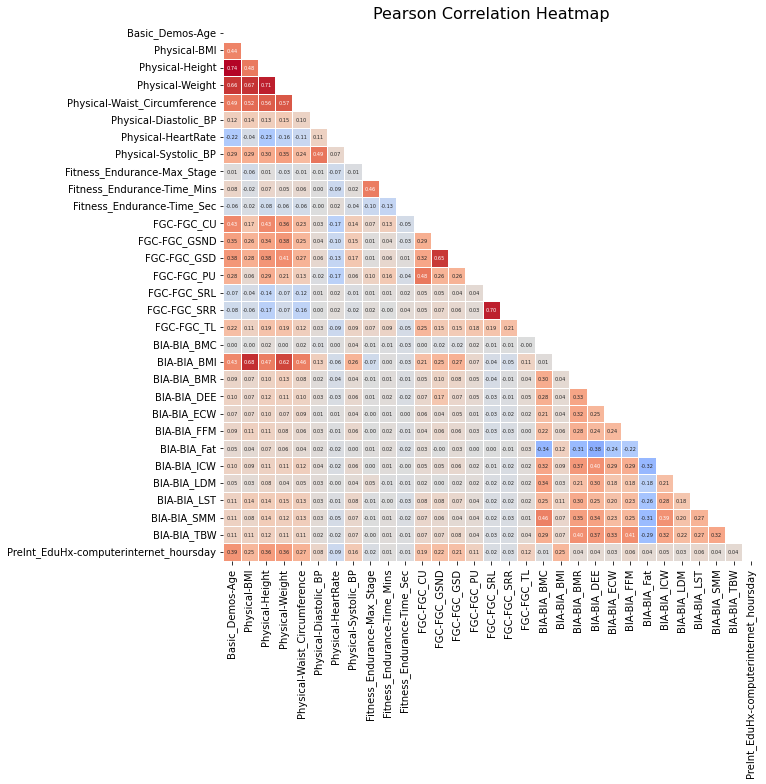

In [314]:

# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# TRAIN DATASET 

## equal

In [315]:
df_train= df[['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-Season', 'PAQ_A-PAQ_A_Total', 'PAQ_C-Season',
       'PAQ_C-PAQ_C_Total', 'PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
       'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
       'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
       'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
       'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
       'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total', 'SDS-Season',
       'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T', 'PreInt_EduHx-Season',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-BMI_CAL',
        'BIA-BIA_TBW_CAL', 'BIA-BIA_LST_CAL']].copy()

In [316]:
df_train=df_train[(round(df_train['Physical-BMI_CAL'],0)==round(df_train['Physical-BMI'],0)) 
         & (round(df_train['Physical-BMI_CAL'],0)==round(df_train['BIA-BIA_BMI'],0)) 
         & (round(df_train['BIA-BIA_TBW'],0)==round(df_train['BIA-BIA_TBW_CAL'],0))
         & (round(df_train['BIA-BIA_LST_CAL'],0)==round(df_train['BIA-BIA_LST'],0))
         & (df_train["BIA-BIA_FFM"] < df_train["Physical-Weight"])]

df_train

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,Physical-BMI_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LST_CAL
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,55.0,NaN,NaN,NaN,Fall,3.0,2.0,16.877316,32.69088,38.91765
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,Fall,46.0,64.0,Summer,0.0,0.0,14.035590,27.05513,39.44961
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,44.0,Summer,31.0,45.0,Winter,0.0,1.0,18.292347,45.99660,58.93379
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,20.0,Winter,27.0,40.0,Fall,3.0,0.0,19.660760,47.22110,59.46429
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,NaN,Spring,39.0,55.0,Fall,2.0,0.0,16.861286,50.47670,63.89544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,3952,Summer,15,0,Spring,40.0,Winter,26.364710,70.50,186.4,...,NaN,Spring,66.0,90.0,Summer,3.0,1.0,26.364710,91.48870,118.43319
3953,3953,Fall,8,0,Spring,65.0,Fall,17.139810,52.50,67.2,...,22.0,Fall,41.0,58.0,Fall,2.0,0.0,17.139810,36.71810,49.33007
3954,3954,Summer,7,1,NaN,NaN,Summer,13.927006,48.50,46.6,...,33.0,Summer,48.0,67.0,Summer,0.0,1.0,13.927006,30.04522,42.81850
3955,3955,Fall,13,0,Spring,60.0,Fall,16.362460,59.50,82.4,...,32.0,Winter,35.0,50.0,Fall,1.0,1.0,16.362460,52.83200,66.28893


In [317]:
df_train.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-BMI_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LST_CAL
count,1841.000000,1841.000000,1841.000000,1666.000000,1841.000000,1841.000000,1841.000000,1188.000000,1826.000000,1833.000000,...,1659.000000,1659.000000,1659.000000,1583.000000,1583.000000,1813.000000,1841.000000,1841.000000,1841.000000,1841.000000
mean,1980.900598,10.378599,0.367192,64.679472,19.403495,56.011266,91.203064,26.429082,68.967141,81.678123,...,1.137432,0.913803,27.328511,41.077069,57.751105,1.058467,0.529603,19.403454,50.155898,63.771689
std,1131.514025,3.499621,0.482170,11.078829,4.992032,7.319750,43.174174,3.648041,13.304691,13.335814,...,1.336295,1.159394,20.229085,10.346176,13.155828,1.067739,0.759232,4.992027,19.371179,25.333783
min,0.000000,5.000000,0.000000,30.000000,11.925153,40.500000,33.200000,19.000000,0.000000,33.000000,...,0.000000,0.000000,0.000000,25.000000,38.000000,0.000000,0.000000,11.925153,21.617290,23.620150
25%,1011.000000,8.000000,0.000000,60.000000,15.954323,50.500000,58.800000,26.000000,61.000000,73.000000,...,0.000000,0.000000,11.000000,34.000000,49.000000,0.000000,0.000000,15.954323,35.950600,45.349270
50%,1983.000000,10.000000,0.000000,65.000000,17.972983,55.000000,78.800000,26.000000,67.000000,81.000000,...,1.000000,1.000000,26.000000,39.000000,55.000000,1.000000,0.000000,17.972983,44.819900,56.883110
75%,2953.000000,13.000000,1.000000,71.000000,21.441500,62.000000,113.600000,26.000000,75.000000,90.000000,...,2.000000,1.000000,40.000000,46.000000,64.000000,2.000000,1.000000,21.441500,60.000700,76.286930
max,3957.000000,22.000000,1.000000,95.000000,53.918413,78.500000,315.000000,50.000000,179.000000,138.000000,...,5.000000,5.000000,93.000000,85.000000,100.000000,3.000000,3.000000,53.918413,143.762100,198.353050


In [318]:
df_train[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df_train["BIA-BIA_SMM"] > df_train["BIA-BIA_FFM"]]

,BIA-BIA_SMM,BIA-BIA_FFM


In [319]:
df_train[["Physical-Weight", "BIA-BIA_FFM"]][(df_train["BIA-BIA_FFM"] > df_train["Physical-Weight"]) & (df_train["Physical-Weight"] > 0) ]

,Physical-Weight,BIA-BIA_FFM


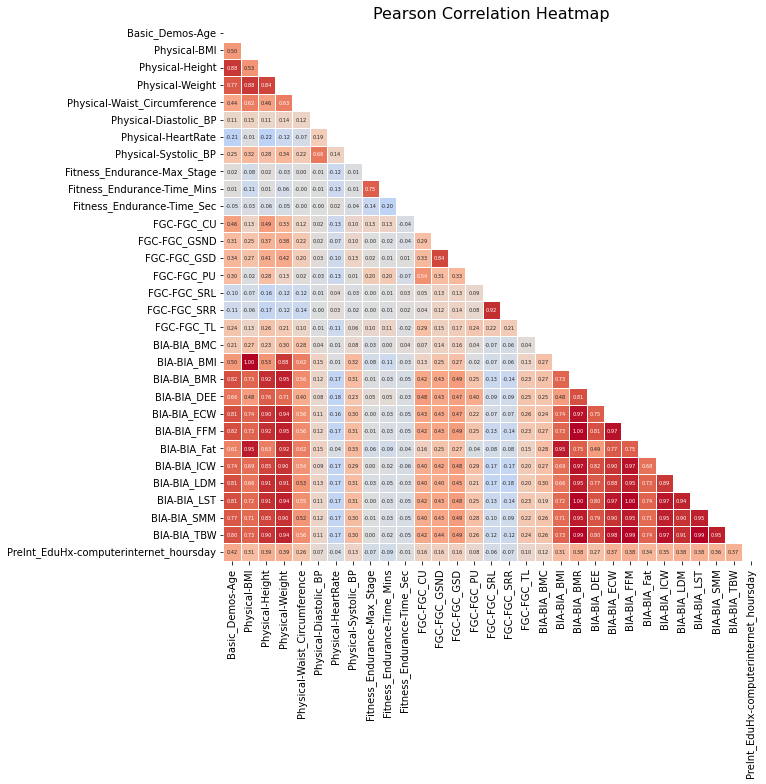

In [320]:

# column selection
df_corr = df_train[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## margin 1

In [321]:
df_train_margin=df.copy()

In [322]:
df_train_margin=df_train_margin[
    (df_train_margin['Physical-BMI_DELTA']<=0.4)
    & (df_train_margin['BIA-BIA_TBW_DELTA']<=0.4)
    & (df_train_margin['BIA-BIA_LST_DELTA']<=0.4)
    & (df_train_margin["BIA-BIA_FFM"] < df_train_margin["Physical-Weight"])]
df_train_margin

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA,Fat_mass
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,38.91765,0.00005,8.8953,6.22677,1864.996,13.816209,0.001491,3.061097,0.000333,6477.985880
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,39.44961,0.00009,14.9739,12.39448,1873.312,12.823983,0.001417,1.211592,0.000128,2791.802880
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,58.93379,0.00001,16.7791,12.93719,3394.290,14.072486,0.001514,4.219861,0.000469,13234.954880
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,79.69814,0.00006,20.9020,16.57164,2661.940,16.685837,0.001863,13.497342,0.001458,47789.126700
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.0,84.6,...,59.46429,0.00001,16.0259,12.24319,2271.720,14.698394,0.001606,4.962367,0.000543,15012.802750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,3952,Summer,15,0,Spring,40.0,Winter,26.364710,70.5,186.4,...,118.43319,0.00019,33.9033,26.94449,5157.930,17.735642,0.001958,8.629068,0.000952,42893.356905
3953,3953,Fall,8,0,Spring,65.0,Fall,17.139810,52.5,67.2,...,49.33007,0.00003,15.8150,12.61197,3105.810,13.398919,0.001481,3.740891,0.000409,10311.958125
3954,3954,Summer,7,1,NaN,NaN,Summer,13.927006,48.5,46.6,...,42.81850,0.00000,15.1400,12.77328,966.287,13.504205,0.272705,0.422801,0.008538,974.450142
3955,3955,Fall,13,0,Spring,60.0,Fall,16.362460,59.5,82.4,...,66.28893,0.00003,17.9797,13.45693,3620.640,14.061330,0.001570,2.301130,0.000250,8147.460545


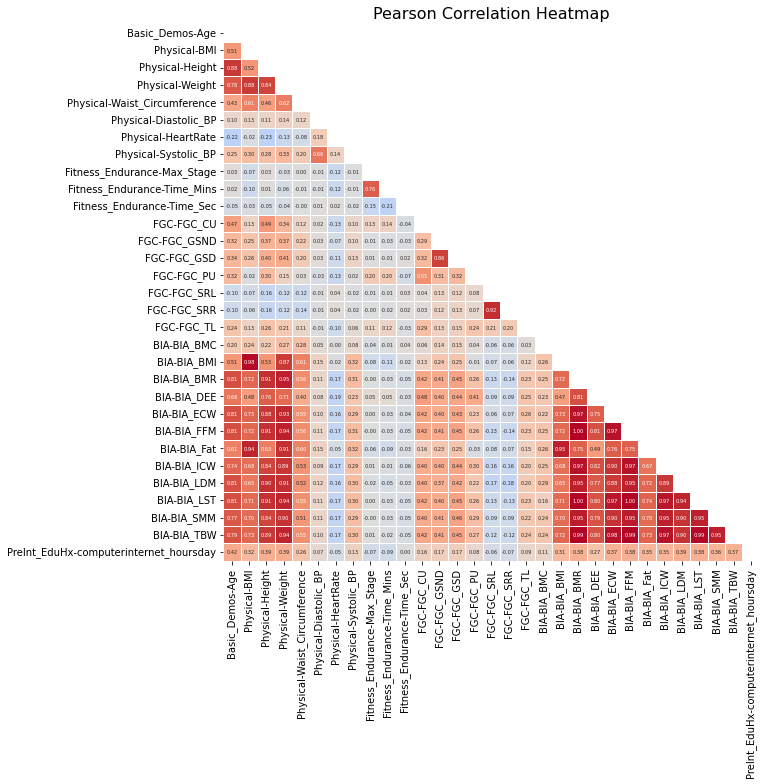

In [323]:
# column selection
df_corr = df_train_margin[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## margin 2

In [324]:
df_train_margin2=df.copy()

In [325]:
df_train_margin2=df_train_margin2[
    (df_train_margin2['Physical-BMI_DELTA']<=0.4)
    & (df_train_margin2['BIA-BIA_TBW_DELTA']<=0.4)
    & (df_train_margin2['BIA-BIA_LST_DELTA']<=0.4)
    & (df_train_margin2['BIA-BIA_FMI_DELTA']<=0.4)
    & (df_train_margin2['BIA-BIA_FFMI_DELTA']<=0.7)
    & (df_train_margin2["BIA-BIA_FFM"] < df_train_margin2["Physical-Weight"])]
df_train_margin2

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA,Fat_mass
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,38.91765,0.00005,8.8953,6.22677,1864.996,13.816209,0.001491,3.061097,0.000333,6477.985880
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,39.44961,0.00009,14.9739,12.39448,1873.312,12.823983,0.001417,1.211592,0.000128,2791.802880
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,58.93379,0.00001,16.7791,12.93719,3394.290,14.072486,0.001514,4.219861,0.000469,13234.954880
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,79.69814,0.00006,20.9020,16.57164,2661.940,16.685837,0.001863,13.497342,0.001458,47789.126700
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.0,84.6,...,59.46429,0.00001,16.0259,12.24319,2271.720,14.698394,0.001606,4.962367,0.000543,15012.802750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,3952,Summer,15,0,Spring,40.0,Winter,26.364710,70.5,186.4,...,118.43319,0.00019,33.9033,26.94449,5157.930,17.735642,0.001958,8.629068,0.000952,42893.356905
3953,3953,Fall,8,0,Spring,65.0,Fall,17.139810,52.5,67.2,...,49.33007,0.00003,15.8150,12.61197,3105.810,13.398919,0.001481,3.740891,0.000409,10311.958125
3954,3954,Summer,7,1,NaN,NaN,Summer,13.927006,48.5,46.6,...,42.81850,0.00000,15.1400,12.77328,966.287,13.504205,0.272705,0.422801,0.008538,974.450142
3955,3955,Fall,13,0,Spring,60.0,Fall,16.362460,59.5,82.4,...,66.28893,0.00003,17.9797,13.45693,3620.640,14.061330,0.001570,2.301130,0.000250,8147.460545


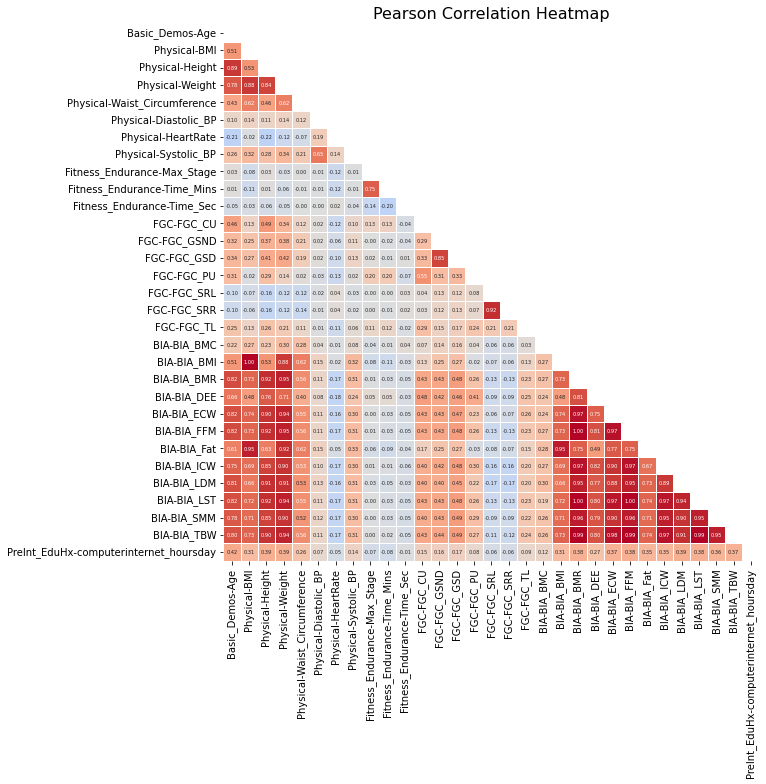

In [326]:
# column selection
df_corr = df_train_margin2[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## margin 3

In [360]:
df_train_margin3 = df.copy()

In [361]:
df_train_margin3

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA,Fat_mass
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,38.917650,0.000050,8.895300,6.226770,1864.996000,13.816209,0.001491,3.061097,0.000333,6477.985880
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,39.449610,0.000090,14.973900,12.394480,1873.312000,12.823983,0.001417,1.211592,0.000128,2791.802880
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,...,57.143480,0.147080,16.079200,NaN,NaN,13.448050,0.644450,3.561984,0.136646,11806.951618
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,58.933790,0.000010,16.779100,12.937190,3394.290000,14.072486,0.001514,4.219861,0.000469,13234.954880
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,Spring,7,1,Spring,NaN,Fall,16.130585,46.07,49.0,...,39.920131,2.765789,10.963074,NaN,979.009933,14.092188,0.468569,1.051290,0.043272,2323.147824
8456,8456,Winter,10,1,Spring,69.5,Winter,NaN,56.13,47.8,...,44.875216,NaN,13.387407,8.329236,3088.234637,11.126133,NaN,1.707244,0.937744,8333.240177
8457,8457,Winter,10,1,Winter,70.0,Winter,40.937571,49.56,47.2,...,47.321049,3.484866,16.204707,2.446471,4137.550396,14.686150,0.550081,-43.522459,49.432475,14516.144322
8458,8458,Fall,15,1,NaN,55.5,Spring,NaN,63.79,99.5,...,NaN,NaN,23.186015,NaN,2759.406893,13.944840,2.252682,4.615988,1.265980,23934.693333


In [362]:
df_train_margin3=df_train_margin3[
    (df_train_margin3['Physical-BMI_DELTA']<=10)
    & (df_train_margin3['BIA-BIA_TBW_DELTA']<=90)
    & (df_train_margin3['BIA-BIA_LST_DELTA']<=180)
    & (df_train_margin3['BIA-BIA_FMI_DELTA']<=30)
    & (df_train_margin3['BIA-BIA_FFMI_DELTA']<=30)
    & (df_train_margin3["BIA-BIA_FFM"] < df_train_margin3["Physical-Weight"])
    & (df_train_margin3["Physical-Diastolic_BP"] < df_train_margin3["Physical-Systolic_BP"])
    & (df_train_margin3["BIA-BIA_SMM"] < df_train_margin3["BIA-BIA_FFM"])   
]
df_train_margin3

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA,Fat_mass
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,39.449610,0.000090,14.973900,12.394480,1873.312000,12.823983,0.001417,1.211592,0.000128,2791.802880
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,58.933790,0.000010,16.779100,12.937190,3394.290000,14.072486,0.001514,4.219861,0.000469,13234.954880
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.50,112.2,...,79.698140,0.000060,20.902000,16.571640,2661.940000,16.685837,0.001863,13.497342,0.001458,47789.126700
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,59.464290,0.000010,16.025900,12.243190,2271.720000,14.698394,0.001606,4.962367,0.000543,15012.802750
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,63.895440,0.000040,17.476000,13.418740,3540.120000,13.607719,0.001481,3.253587,0.000363,11423.194847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8371,8371,Spring,6,0,NaN,65.5,Spring,15.496182,46.84,64.7,...,44.471224,0.597147,14.090851,12.223378,983.596006,15.015783,1.236076,3.129285,0.957246,4765.423706
8406,8406,Summer,10,1,Spring,61.5,Spring,17.057230,58.32,75.1,...,55.244640,93.738133,17.303658,5.840319,NaN,12.511726,2.773394,4.207823,0.024281,14394.324045
8426,8426,Fall,7,0,Winter,77.0,Fall,18.020412,64.24,72.4,...,51.121736,9.092650,16.696690,6.228290,2178.221633,9.775933,4.360739,2.321323,6.512262,36454.241664
8440,8440,Summer,10,1,Winter,59.5,Fall,17.322879,55.10,72.0,...,54.080156,6.436603,17.905819,12.705795,4652.546409,13.666413,0.483856,4.479695,0.706816,11454.499282


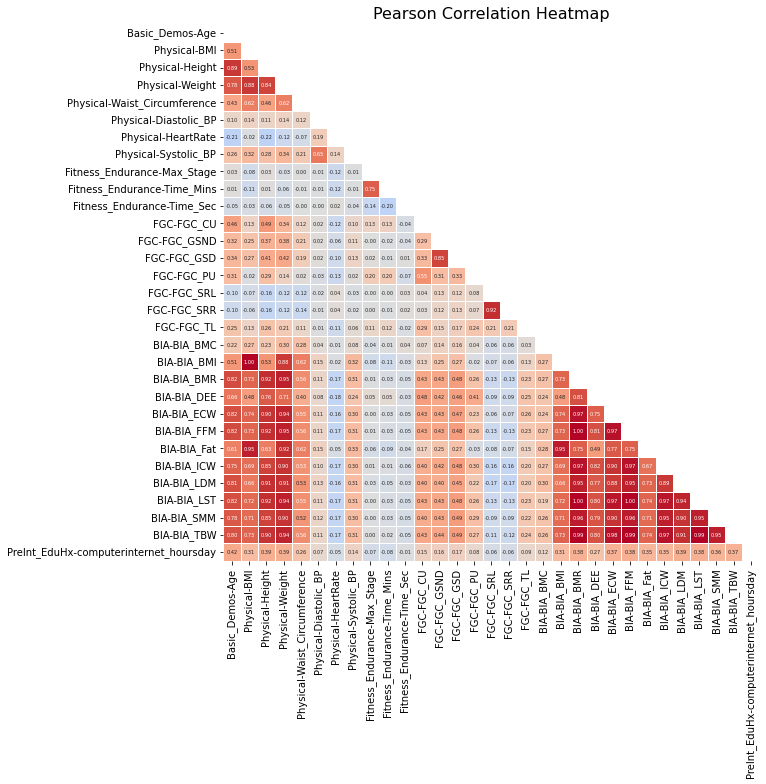

In [359]:
# column selection
df_corr = df_train_margin2[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# DATASET READY FOR CLEANING

In [354]:
file_path = "../1.DATASET/cmi_internet.csv"
df_clean=pd.read_csv(file_path)

In [355]:
df_clean=df_clean[[
    'Basic_Demos-Age', 
    'Basic_Demos-Sex',
    'CGAS-CGAS_Score', 
    'Physical-BMI',
    'Physical-Height', 
    'Physical-Weight',
    'Physical-Waist_Circumference',
    'Physical-Diastolic_BP',
    'Physical-HeartRate', 
    'Physical-Systolic_BP',
    'Fitness_Endurance-Max_Stage',
    'FGC-FGC_CU', 
    'FGC-FGC_GSND',
    'FGC-FGC_GSD', 
    'FGC-FGC_PU',
    'FGC-FGC_SRL', 
    'FGC-FGC_SRR',
    'FGC-FGC_TL', 
    'BIA-BIA_Activity_Level_num',
    'BIA-BIA_BMC',
    'BIA-BIA_DEE',
    'BIA-BIA_FFMI', 
    'BIA-BIA_FMI', 
    'BIA-BIA_Fat',
    'BIA-BIA_Frame_num',
    'BIA-BIA_SMM',
    'BIA-BIA_TBW', 
    'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
    'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
    'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
    'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
    'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
    'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total', 
    'SDS-SDS_Total_T', 
    'PreInt_EduHx-computerinternet_hoursday', 'sii']]

In [356]:
df_clean['PCIAT-PCIAT_Total']

0       55.0
1        0.0
2       28.0
3       44.0
4        NaN
        ... 
8455     NaN
8456     NaN
8457     NaN
8458     NaN
8459     NaN
Name: PCIAT-PCIAT_Total, Length: 8460, dtype: float64